# Diffusion Models

Verify forward noising and a small continuous-fraction noise predictor. Then train a separate discrete-time denoiser on a four-mode distribution, select with validation noise MSE, and run a complete DDPM reverse sampler from fresh Gaussian noise.

In [1]:
import torch
from torch import nn

torch.manual_seed(40)
torch.set_num_threads(1)
print('CPU | diffusion noising and noise prediction')

CPU | diffusion noising and noise prediction


In [2]:
clean = torch.tensor([[2.]], dtype=torch.float64)
noise = torch.tensor([[-1.]], dtype=torch.float64)
alpha_bar = torch.tensor(0.81, dtype=torch.float64)
noisy = alpha_bar.sqrt() * clean + (1 - alpha_bar).sqrt() * noise
torch.testing.assert_close(noisy, torch.tensor([[1.3641101056459328]], dtype=torch.float64))
print('clean:', clean.item(), '| noise:', noise.item(), '| noisy:', noisy.item())

clean: 2.0 | noise: -1.0 | noisy: 1.3641101056459328


In [3]:
data = torch.randn(256, 2) * 0.6 + torch.tensor([1., -1.])
denoiser = nn.Sequential(nn.Linear(3, 32), nn.Tanh(), nn.Linear(32, 2))
optimizer = torch.optim.Adam(denoiser.parameters(), lr=0.01)
for _ in range(80):
    clean_batch = data[torch.randint(len(data), (64,))]
    step = torch.rand(64, 1)
    noise_batch = torch.randn_like(clean_batch)
    noisy_batch = (1 - step).sqrt() * clean_batch + step.sqrt() * noise_batch
    prediction = denoiser(torch.cat([noisy_batch, step], dim=1))
    loss = nn.functional.mse_loss(prediction, noise_batch)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
assert torch.isfinite(loss)
print(f'tiny noise-prediction loss={loss.item():.4f}')

tiny noise-prediction loss=0.3452


## Complete project: learn a denoiser and run a DDPM reverse sampler

The initial example trains a noise predictor only. Here we define a discrete schedule, train on a four-mode two-dimensional distribution, select using fixed validation corruptions, and sample fresh points by running every reverse step. Separate held-out observations support a final noise-prediction measurement and distribution comparison.

Each mode is a Gaussian centered at a corner of a square, with standard deviation 0.25 per coordinate. Modes are equally likely. This small distribution makes missing modes and incorrect spread visible. It is not an image-generation experiment.

For step $t$, define $\alpha_t=1-\beta_t$ and $\bar\alpha_t=\prod_{s\leq t}\alpha_s$. Training samples $x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$. The learned network receives both $x_t$ and a time embedding.

In [4]:
import math, copy
from IPython import get_ipython
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib.pyplot as plt
import torch.nn.functional as F

torch.manual_seed(400)
centers = torch.tensor([[-1.5, -1.5], [-1.5, 1.5], [1.5, -1.5], [1.5, 1.5]])
def draw_mixture(count, seed):
    generator = torch.Generator().manual_seed(seed)
    component = torch.randint(4, (count,), generator=generator)
    return centers[component] + 0.25 * torch.randn(count, 2, generator=generator)

diff_train = draw_mixture(2048, 401)
diff_valid = draw_mixture(512, 402)
diff_test = draw_mixture(512, 403)
T = 100
betas = torch.linspace(0.0001, 0.12, T)
alphas = 1 - betas
alpha_bars = alphas.cumprod(0)
previous_bars = torch.cat([torch.ones(1), alpha_bars[:-1]])
posterior_variance = betas * (1 - previous_bars) / (1 - alpha_bars)
assert (alpha_bars[1:] < alpha_bars[:-1]).all()
assert posterior_variance[0] == 0 and alpha_bars[-1] < 0.002
print('final cumulative retention:', alpha_bars[-1].item())
print('clean population covariance diagonal:', 1.5 ** 2 + 0.25 ** 2)

def corrupt(clean, steps, noise):
    assert steps.shape == (len(clean),) and clean.shape == noise.shape
    retained = alpha_bars[steps].unsqueeze(1)
    return retained.sqrt() * clean + (1 - retained).sqrt() * noise

class NoisePredictor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(10, 64), nn.SiLU(), nn.Linear(64, 64),
                                 nn.SiLU(), nn.Linear(64, 2))
        self.register_buffer('frequencies', torch.tensor([1., 2., 4., 8.]) * math.pi)
    def forward(self, points, steps):
        angle = (steps.float() / (T - 1)).unsqueeze(1) * self.frequencies
        time_features = torch.cat([angle.sin(), angle.cos()], dim=1)
        return self.net(torch.cat([points, time_features], dim=1))

noise_model = NoisePredictor()

final cumulative retention: 0.0019072103314101696
clean population covariance diagonal: 2.3125


### Hold validation corruptions fixed

Fresh training noise creates new supervised targets each update. Fixed validation noise and time indices make checkpoint comparisons less noisy. Validation selects by noise MSE, not by inspecting generated test samples. This objective does not guarantee sample quality; we inspect the completed sampler separately.

In [5]:
validation_rng = torch.Generator().manual_seed(404)
valid_steps = torch.randint(T, (len(diff_valid),), generator=validation_rng)
valid_epsilon = torch.randn(diff_valid.shape, generator=validation_rng)
valid_noisy = corrupt(diff_valid, valid_steps, valid_epsilon)
diff_optimizer = torch.optim.Adam(noise_model.parameters(), lr=0.001)
training_rng = torch.Generator().manual_seed(405)
diff_history = []
best_diff_loss, best_diff_update, best_diff_state = float('inf'), None, None
for update in range(1, 2001):
    noise_model.train()
    indices = torch.randint(len(diff_train), (128,), generator=training_rng)
    times = torch.randint(T, (128,), generator=training_rng)
    epsilon = torch.randn(128, 2, generator=training_rng)
    noisy_points = corrupt(diff_train[indices], times, epsilon)
    loss = F.mse_loss(noise_model(noisy_points, times), epsilon)
    diff_optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(noise_model.parameters(), 1.0)
    diff_optimizer.step()
    if update % 50 == 0:
        noise_model.eval()
        with torch.no_grad():
            valid_loss = F.mse_loss(noise_model(valid_noisy, valid_steps), valid_epsilon).item()
        diff_history.append((update, loss.item(), valid_loss))
        if valid_loss < best_diff_loss:
            best_diff_loss, best_diff_update = valid_loss, update
            best_diff_state = copy.deepcopy(noise_model.state_dict())
assert best_diff_state is not None and torch.isfinite(torch.tensor(diff_history)).all()
noise_model.load_state_dict(best_diff_state)
noise_model.eval()
print('selected update:', best_diff_update, '| validation noise MSE:', round(best_diff_loss, 4))

selected update: 1900 | validation noise MSE: 0.313


### Reverse mean, variance, and the final step

Using zero-based indices in code, the reverse mean is

$$\mu_\theta(x_t,t)=\frac{x_t-\beta_t\epsilon_\theta(x_t,t)/\sqrt{1-\bar\alpha_t}}{\sqrt{\alpha_t}}.$$

For nonfinal reverse steps, add Gaussian noise with variance $\tilde\beta_t=\beta_t(1-\bar\alpha_{t-1})/(1-\bar\alpha_t)$. The final step uses the mean alone. The sampler starts with fresh standard-normal noise, not an observed clean test point. Terminal retention is small but nonzero, so the starting Gaussian is an approximation to the terminal forward distribution.

In [6]:
def reverse_mean(points, steps, epsilon_prediction):
    beta = betas[steps].unsqueeze(1)
    alpha = alphas[steps].unsqueeze(1)
    retained = alpha_bars[steps].unsqueeze(1)
    return (points - beta * epsilon_prediction / (1 - retained).sqrt()) / alpha.sqrt()

# An oracle noise prediction gives the known posterior mean for a selected clean/noisy pair.
probe_x0 = torch.tensor([[1.2, -0.7]], dtype=torch.float64)
probe_epsilon = torch.tensor([[-0.2, 0.8]], dtype=torch.float64)
probe_t = 30
bt, at = betas[probe_t].double(), alphas[probe_t].double()
ab, ab_prev = alpha_bars[probe_t].double(), previous_bars[probe_t].double()
probe_xt = ab.sqrt() * probe_x0 + (1 - ab).sqrt() * probe_epsilon
oracle_mean = (probe_xt - bt * probe_epsilon / (1 - ab).sqrt()) / at.sqrt()
posterior_mean = ab_prev.sqrt() * bt / (1 - ab) * probe_x0 + at.sqrt() * (1 - ab_prev) / (1 - ab) * probe_xt
# Float32 schedule rounding affects the independently rearranged formula.
torch.testing.assert_close(oracle_mean, posterior_mean, rtol=1e-5, atol=1e-6)

@torch.no_grad()
def sample_ddpm(count=1024, seed=406):
    generator = torch.Generator().manual_seed(seed)
    points = torch.randn(count, 2, generator=generator)
    trajectory = {T: points.clone()}
    noise_model.eval()
    for index in range(T - 1, -1, -1):
        steps = torch.full((count,), index, dtype=torch.long)
        points = reverse_mean(points, steps, noise_model(points, steps))
        if index > 0:
            points = points + posterior_variance[index].sqrt() * torch.randn(points.shape, generator=generator)
        if index in [75, 50, 25, 0]:
            trajectory[index] = points.clone()
    assert points.shape == (count, 2) and torch.isfinite(points).all()
    return points, trajectory

generated_points, reverse_trajectory = sample_ddpm()
a, _ = sample_ddpm(16, 407)
b, _ = sample_ddpm(16, 407)
c, _ = sample_ddpm(16, 408)
torch.testing.assert_close(a, b)
assert not torch.allclose(a, c)
print('generated points:', tuple(generated_points.shape), '| reproducibility and finite checks passed')

generated points: (1024, 2) | reproducibility and finite checks passed


held-out noise MSE=0.3041 | zero-prediction baseline=0.9192
Held-out real | mean: [-0.14687299728393555, -0.05573128163814545] | std: [1.4974520206451416, 1.5023492574691772] | nearest-mode proportions: [0.25390625, 0.29296875, 0.265625, 0.1875] | nearest-center distance: 0.3057
DDPM generated | mean: [-0.17479388415813446, 0.043937213718891144] | std: [1.4907783269882202, 1.4207991361618042] | nearest-mode proportions: [0.2900390625, 0.255859375, 0.2119140625, 0.2421875] | nearest-center distance: 0.3862


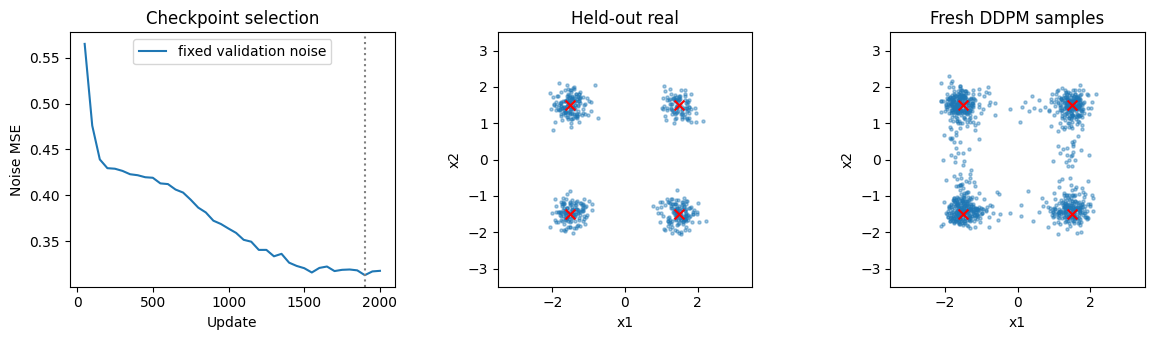

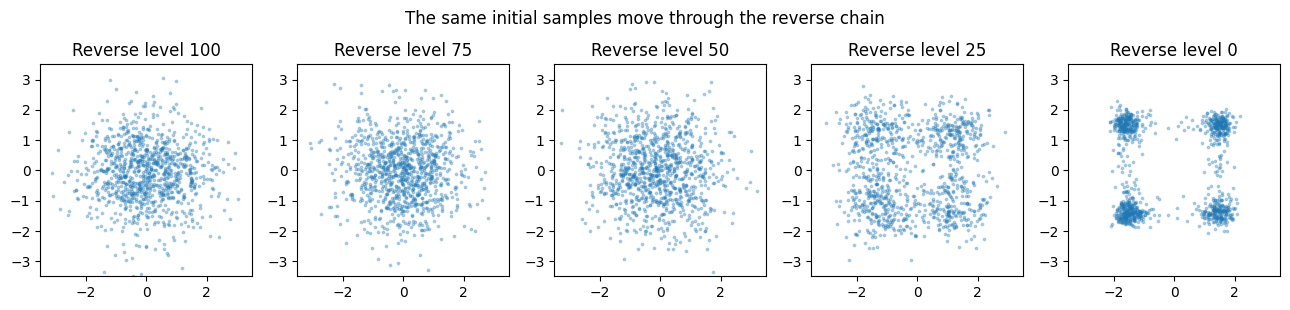

In [7]:
@torch.no_grad()
def mixture_summary(points):
    distances = torch.cdist(points, centers)
    assignment = distances.argmin(1)
    proportions = torch.bincount(assignment, minlength=4).float() / len(points)
    nearest_distance = distances.min(1).values.mean().item()
    return points.mean(0), points.std(0, unbiased=False), proportions, nearest_distance

test_rng = torch.Generator().manual_seed(409)
test_steps = torch.randint(T, (len(diff_test),), generator=test_rng)
test_noise = torch.randn(diff_test.shape, generator=test_rng)
with torch.no_grad():
    diff_test_mse = F.mse_loss(noise_model(corrupt(diff_test, test_steps, test_noise), test_steps), test_noise).item()
zero_noise_mse = test_noise.square().mean().item()
print(f'held-out noise MSE={diff_test_mse:.4f} | zero-prediction baseline={zero_noise_mse:.4f}')
for name, points in [('Held-out real', diff_test), ('DDPM generated', generated_points)]:
    mean, std, proportions, distance = mixture_summary(points)
    print(name, '| mean:', mean.tolist(), '| std:', std.tolist(),
          '| nearest-mode proportions:', proportions.tolist(), '| nearest-center distance:', round(distance, 4))
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].plot([r[0] for r in diff_history], [r[2] for r in diff_history], label='fixed validation noise')
axes[0].axvline(best_diff_update, color='gray', linestyle=':'); axes[0].legend()
axes[0].set(xlabel='Update', ylabel='Noise MSE', title='Checkpoint selection')
for ax, points, title in zip(axes[1:], [diff_test, generated_points], ['Held-out real', 'Fresh DDPM samples']):
    ax.scatter(points[:, 0], points[:, 1], s=5, alpha=0.4)
    ax.scatter(centers[:, 0], centers[:, 1], marker='x', c='red', s=50)
    ax.set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), title=title, xlabel='x1', ylabel='x2'); ax.set_aspect('equal')
fig.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 5, figsize=(13, 3))
for ax, index in zip(axes, [T, 75, 50, 25, 0]):
    points = reverse_trajectory[index]
    ax.scatter(points[:, 0], points[:, 1], s=3, alpha=0.3)
    ax.set(xlim=(-3.5, 3.5), ylim=(-3.5, 3.5), title=f'Reverse level {index}'); ax.set_aspect('equal')
fig.suptitle('The same initial samples move through the reverse chain')
fig.tight_layout(); plt.show()

### Read the evidence honestly

The companion now implements the full chain: defined data distribution → forward corruption → validation-selected denoiser → reverse Gaussian transitions → fresh generated samples. Noise MSE compares predictive behavior on excluded observations. Means, spreads, nearest-mode proportions, and plots assess different aspects of sampling behavior. Nearest-mode assignment puts even poor samples into a mode, so proportions alone cannot demonstrate quality; inspect distances and scatter plots too. Matching these summaries does not establish exact distribution equality.
